In [1]:
import torch
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# import data
data = pd.read_csv("concrete_data.csv")
data.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [3]:
# Dataset info
dataset_shape = data.shape
column_names = data.columns.tolist()

# Display results
print("Dataset shape:", dataset_shape)
print("Column names:", column_names)

Dataset shape: (1030, 9)
Column names: ['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate', 'Age', 'Strength']


In [4]:
# Check for missing values
print(data.isnull().sum())

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64


In [5]:
# Inputs: all columns except the last one
inputs = data.iloc[:, :-1].values

# Targets: only the last column
targets = data.iloc[:, -1].values.reshape(-1, 1)

print("Input shape:", inputs.shape)
print("Target shape:", targets.shape)

Input shape: (1030, 8)
Target shape: (1030, 1)


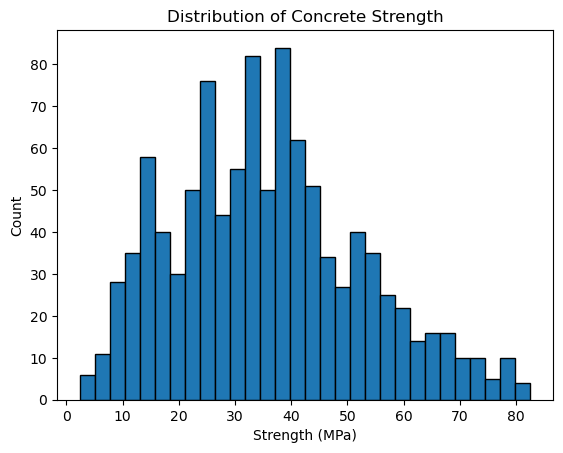

In [6]:
# Plot histogram for the target variable (Concrete Strength)
plt.hist(targets, bins=30, edgecolor='k')
plt.title('Distribution of Concrete Strength')
plt.xlabel('Strength (MPa)')
plt.ylabel('Count')
plt.show()

<Figure size 1200x600 with 0 Axes>

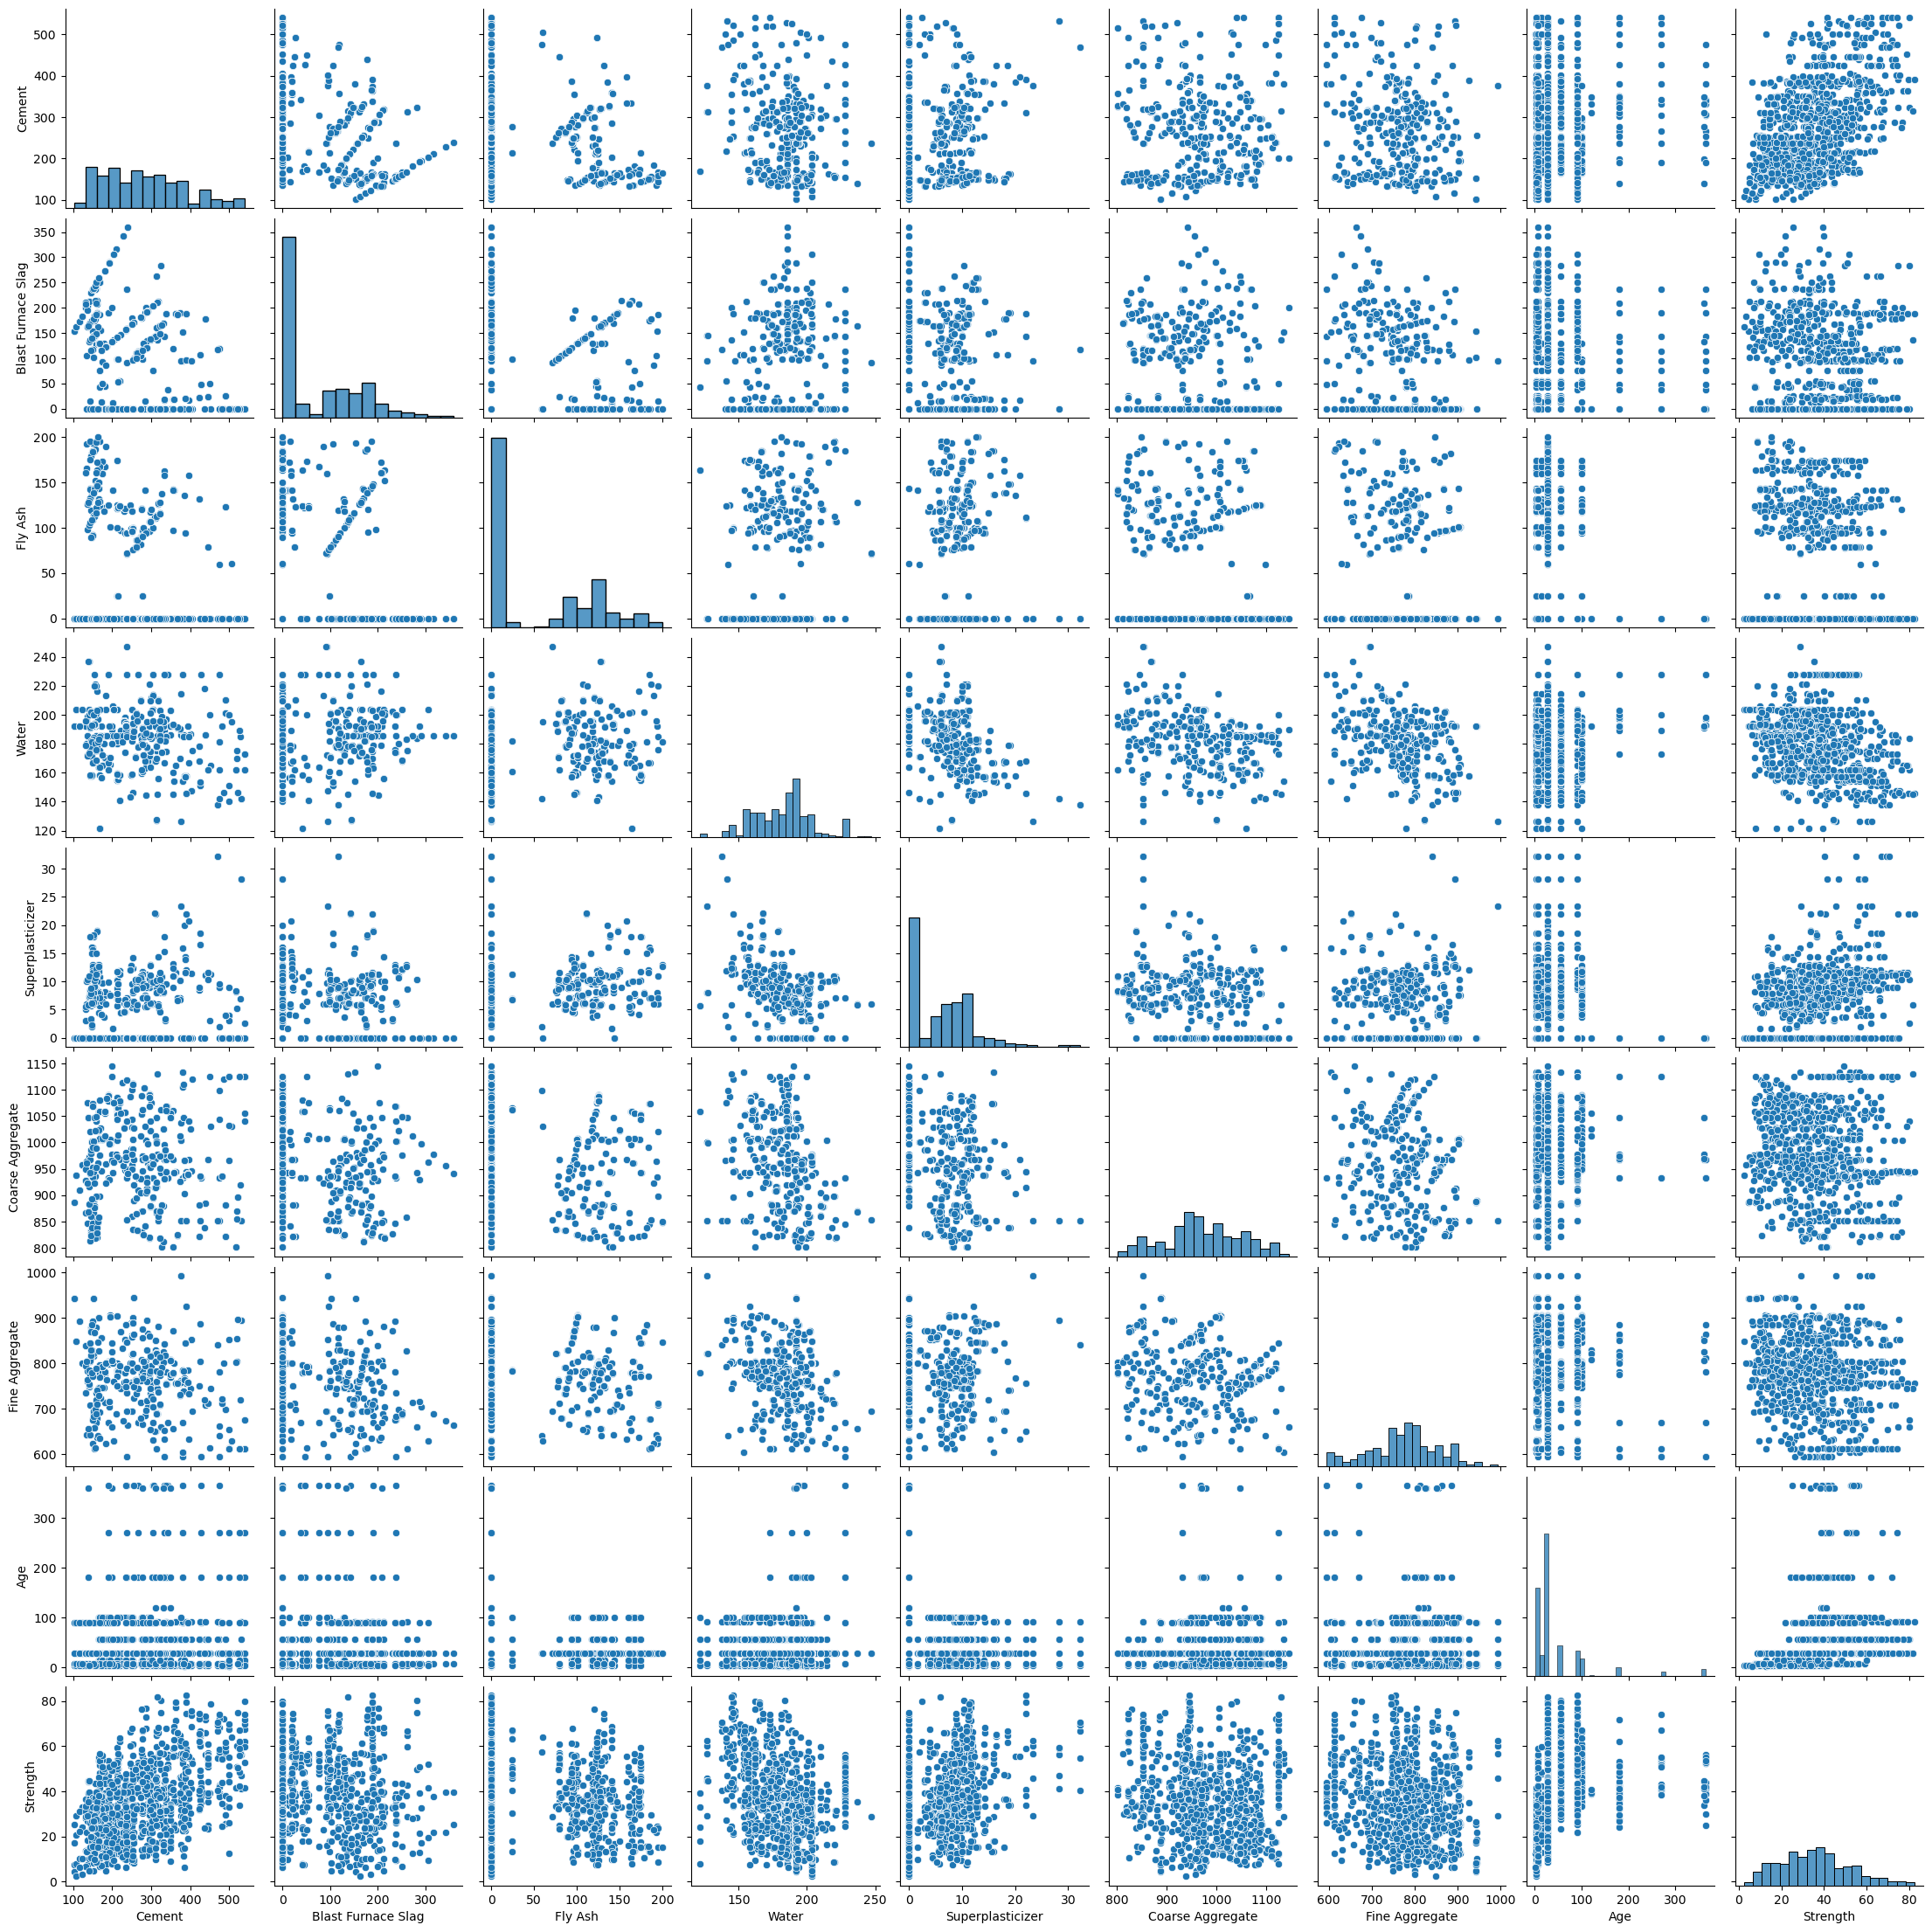

In [7]:
# correlation plot
plt.figure(figsize=(12, 6))
sns.pairplot(data)
plt.show()

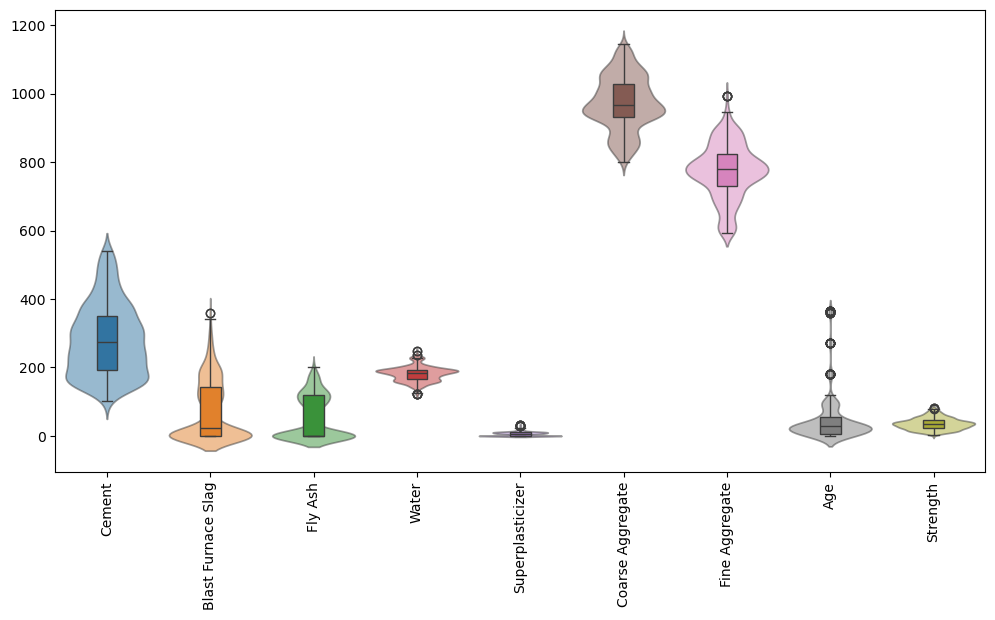

In [8]:
# violin plot

plt.figure(figsize=(12, 6))
sns.violinplot(data=data, alpha=0.5, inner=None)
sns.boxplot(data=data, width=0.2, showfliers=True)
plt.xticks(rotation=90)
plt.show()

In [9]:
# shuffle and split data into training (80%) and test (20%)
torch.manual_seed(42)
n_samples = inputs.shape[0]
indicies = torch.randperm(n_samples)
split_idx = int(n_samples * .8)

train_indicies = indicies[:split_idx]
test_indicies = indicies[split_idx:]

X_tr = inputs[train_indicies]
y_tr = targets[train_indicies]
X_te = inputs[test_indicies]
y_te = targets[test_indicies]

# scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_tr)
X_test_scaled = scaler.transform(X_te)

# convert to tensors
X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train = torch.tensor(y_tr, dtype=torch.float32)
X_test = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test = torch.tensor(y_te, dtype=torch.float32)

In [10]:
# initialize model parameters
num_features = X_train.shape[1]    # should be 8
W = torch.randn((num_features, 1), requires_grad=True)
W.data *= 0.01  # scale down initial values
b = torch.zeros((1,), requires_grad=True)

# confirm everything is set up
print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])
print("Weight shape:", W.shape)
print("Bias shape:", b.shape)

Training set size: 824
Test set size: 206
Weight shape: torch.Size([8, 1])
Bias shape: torch.Size([1])


In [11]:
# define predict function (ŷ = XW + b)
def predict(X):
    return torch.matmul(X, W) + b

# mean squared error (MSE) function
def mse_loss(predictions, targets):
    return torch.mean((predictions - targets) ** 2)

# mean absolute error (MAE) function
def mae_loss(predictions, targets):
    return torch.mean(torch.abs(targets - predictions))

epoch 1: loss = 1575.6338
epoch 51: loss = 1306.7098
epoch 101: loss = 1087.6418
epoch 151: loss = 909.1010
epoch 201: loss = 763.5221
epoch 251: loss = 644.7657
epoch 301: loss = 547.8471
epoch 351: loss = 468.7153
epoch 401: loss = 404.0781
epoch 451: loss = 351.2566
epoch 501: loss = 308.0719
epoch 551: loss = 272.7492
epoch 601: loss = 243.8434
epoch 651: loss = 220.1768
epoch 701: loss = 200.7891
epoch 751: loss = 184.8973
epoch 801: loss = 171.8631
epoch 851: loss = 161.1650
epoch 901: loss = 152.3775
epoch 951: loss = 145.1531


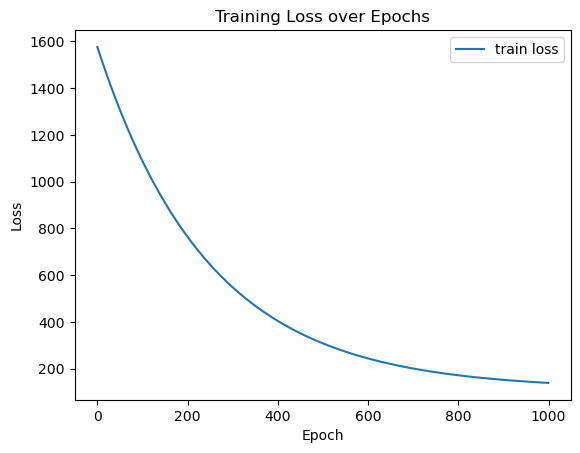

In [12]:
# Initialize list to store loss values
losses = []

# set learning rate and number of training epochs
learning_rate = 0.001
epochs = 1000

# training loop
for epoch in range(epochs):
    # 1. forward pass: compute predictions
    y_pred = predict(X_train)

    # 2. compute loss
    loss = mse_loss(y_pred, y_train)
    losses.append(loss.item())    # track the loss

    # 3. backward pass: compute gradients
    loss.backward()

    # 4. update parameters
    with torch.no_grad():
        W -= learning_rate * W.grad
        b -= learning_rate * b.grad

    # 5. zero gradients
    W.grad.zero_()
    b.grad.zero_()

    # print loss every 10 epochs
    if (epoch) % 50 == 0:
        print(f'epoch {epoch+1}: loss = {loss.item():.4f}')

# plot loss curve
plt.plot(losses, label='train loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss over Epochs")
plt.legend()
plt.show()

In [13]:
# evaluate the model on test set

# step 1: predict on test data
y_test_pred = predict(X_test)

# step 2: compute MSE on test set
test_loss = mse_loss(y_test_pred, y_test)

# step 3: print the result
print(f"Test Loss: {test_loss.item():.4f}")

# Step 4: Compute MAE
test_mae_loss = mae_loss(y_test_pred, y_test)

# Step 5: print result
print(f"Test MAE Loss: {test_mae_loss.item():.4f}")


Test Loss: 143.6791
Test MAE Loss: 9.6587
